In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import beta

customer_data = pd.read_csv(
    "/content/drive/MyDrive/Data/data/processed/customer_clv_model.csv"
)

# Bayesian Repeat-Purchase Analysis

A Bayesian Beta-Binomial model is used to estimate and compare the repeat-purchase probabilities of UK and non-UK customers.

For each customer group, the number of returning customers follows a binomial distribution:

$$
X_g\mid p_g\sim\text{Binomial}(n_g,p_g)
$$

where \(p_g\) represents the unknown repeat-purchase probability.

A uniform Beta prior is assigned:

$$
p_g\sim\text{Beta}(1,1)
$$

After observing \(x_g\) returning customers from \(n_g\) customers, the posterior distribution becomes:

$$
p_g\mid X_g
\sim
\text{Beta}(1+x_g,\;1+n_g-x_g)
$$

The posterior distribution combines the prior belief with the observed customer data.


In [ ]:
uk_data = customer_data[
    customer_data["IsUK"] == 1
]

nonuk_data = customer_data[
    customer_data["IsUK"] == 0
]

n_uk = len(uk_data)
x_uk = uk_data["RepeatPurchase"].sum()

n_nonuk = len(nonuk_data)
x_nonuk = nonuk_data[
    "RepeatPurchase"
].sum()

print("UK customers:", n_uk)
print("UK repeat customers:", x_uk)

print("\nNon-UK customers:", n_nonuk)
print("Non-UK repeat customers:", x_nonuk)

UK customers: 3929
UK repeat customers: 2499

Non-UK customers: 337
Non-UK repeat customers: 227


In [ ]:
prior_alpha = 1
prior_beta = 1

uk_alpha = prior_alpha + x_uk
uk_beta = prior_beta + n_uk - x_uk

nonuk_alpha = prior_alpha + x_nonuk
nonuk_beta = prior_beta + n_nonuk - x_nonuk

In [ ]:
uk_posterior_mean = (
    uk_alpha /
    (uk_alpha + uk_beta)
)

nonuk_posterior_mean = (
    nonuk_alpha /
    (nonuk_alpha + nonuk_beta)
)

uk_credible_interval = beta.ppf(
    [0.025, 0.975],
    uk_alpha,
    uk_beta
)

nonuk_credible_interval = beta.ppf(
    [0.025, 0.975],
    nonuk_alpha,
    nonuk_beta
)

bayesian_summary = pd.DataFrame({
    "Group": ["UK", "Non-UK"],
    "Customers": [n_uk, n_nonuk],
    "RepeatCustomers": [x_uk, x_nonuk],
    "PosteriorMean": [
        uk_posterior_mean,
        nonuk_posterior_mean
    ],
    "CredibleLower": [
        uk_credible_interval[0],
        nonuk_credible_interval[0]
    ],
    "CredibleUpper": [
        uk_credible_interval[1],
        nonuk_credible_interval[1]
    ]
})

bayesian_summary.round(4)

,Group,Customers,RepeatCustomers,PosteriorMean,CredibleLower,CredibleUpper
0,UK,3929,2499,0.6360,0.6209,0.6509
1,Non-UK,337,227,0.6726,0.6218,0.7214


In [ ]:
rng = np.random.default_rng(42)

uk_samples = rng.beta(
    uk_alpha,
    uk_beta,
    size=100000
)

nonuk_samples = rng.beta(
    nonuk_alpha,
    nonuk_beta,
    size=100000
)

difference_samples = (
    uk_samples - nonuk_samples
)

probability_uk_higher = np.mean(
    difference_samples > 0
)

difference_interval = np.quantile(
    difference_samples,
    [0.025, 0.975]
)

print(
    "Probability that UK repeat rate "
    f"is higher: {probability_uk_higher:.4f}"
)

print(
    "95% credible interval for difference:",
    np.round(difference_interval, 4)
)

Probability that UK repeat rate is higher: 0.0860
95% credible interval for difference: [-0.0882  0.0162]


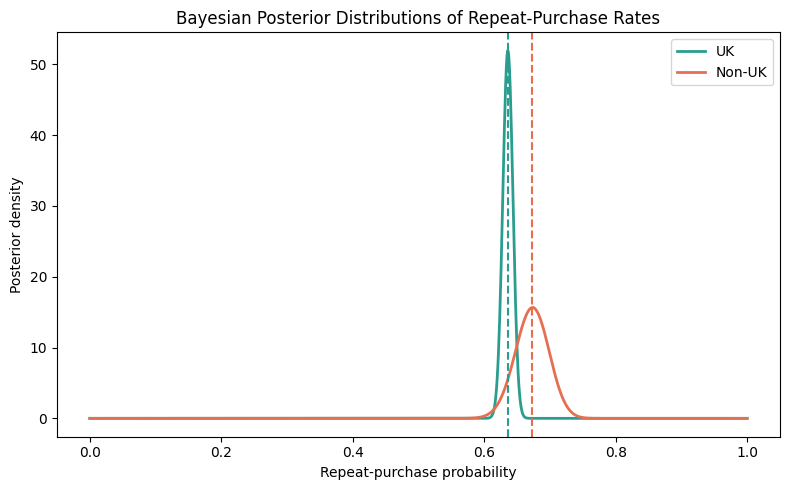

In [ ]:
probability_values = np.linspace(
    0,
    1,
    1000
)

uk_density = beta.pdf(
    probability_values,
    uk_alpha,
    uk_beta
)

nonuk_density = beta.pdf(
    probability_values,
    nonuk_alpha,
    nonuk_beta
)

plt.figure(figsize=(8, 5))

plt.plot(
    probability_values,
    uk_density,
    label="UK",
    color="#2A9D8F",
    linewidth=2
)

plt.plot(
    probability_values,
    nonuk_density,
    label="Non-UK",
    color="#E76F51",
    linewidth=2
)

plt.axvline(
    uk_posterior_mean,
    color="#2A9D8F",
    linestyle="--"
)

plt.axvline(
    nonuk_posterior_mean,
    color="#E76F51",
    linestyle="--"
)

plt.xlabel("Repeat-purchase probability")
plt.ylabel("Posterior density")
plt.title(
    "Bayesian Posterior Distributions "
    "of Repeat-Purchase Rates"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "bayesian_repeat_purchase.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Bayesian Results and Interpretation

The posterior mean repeat-purchase probability was 0.6360 for UK customers and 0.6726 for non-UK customers.

The 95% credible intervals were:

$$p_{\text{UK}} \in [0.6209,\;0.6509]$$

$$p_{\text{Non-UK}} \in [0.6218,\;0.7214]$$

The wider credible interval for non-UK customers is caused by their smaller sample size of 337 customers, compared with 3,929 UK customers.

The posterior probability that the UK repeat-purchase rate is higher than the non-UK rate was only 0.086. Equivalently, there is approximately a 91.4% posterior probability that the non-UK repeat-purchase rate is higher.

However, the 95% credible interval for the difference ($p_{\text{UK}} - p_{\text{Non-UK}}$) was:

$$[-0.0882,\;0.0162]$$

Because this interval includes zero, the analysis does not provide sufficiently strong evidence of a definite difference between the two groups. The results suggest that non-UK customers may have a higher repeat-purchase probability, but uncertainty remains because of the smaller non-UK sample.